In [2]:
from google.colab import drive

drive.mount('/content/drive')
path = '/content/drive/My Drive/Datasheet/credit_card_fraud_10k.csv'

Mounted at /content/drive


In [3]:
import pandas as pd

df = pd.read_csv(path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [5]:
df.drop(columns='transaction_id',inplace=True)

In [6]:
df.head(10)

,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,84.47,22,Electronics,0,0,66,3,40,0
1,541.82,3,Travel,1,0,87,1,64,0
2,237.01,17,Grocery,0,0,49,1,61,0
3,164.33,4,Grocery,0,1,72,3,34,0
4,30.53,15,Food,0,0,79,0,44,0
5,30.53,13,Clothing,0,0,90,2,46,0
6,10.77,18,Travel,0,0,48,1,28,0
7,362.02,13,Electronics,0,0,68,1,40,0
8,165.43,8,Grocery,0,0,80,0,21,0
9,221.63,5,Grocery,0,0,59,1,34,0


In [7]:
df.isnull().sum()

,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


In [8]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,9849
1,151


In [9]:
df['is_fraud'].value_counts(normalize=True)*100

,proportion
is_fraud,
0,98.49
1,1.51


**Feature Engineering**

In [10]:
import numpy as np

df['hour_sin'] = np.sin(2 * np.pi * df['transaction_hour']/24)
df['hour_cos'] = np.sin(2 * np.pi * df['transaction_hour']/24)

In [11]:
df.columns

Index(['amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud', 'hour_sin',
       'hour_cos'],
      dtype='object')

**Preprocessing**

In [12]:
Feature = ['amount','hour_sin','hour_cos','foreign_transaction','location_mismatch','device_trust_score','velocity_last_24h','cardholder_age']
X = df[Feature]
y = df['is_fraud']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)
print(f"Jumlah data latih {len(X_train)} dan data uji {len(X_test)}")

Jumlah data latih 8000 dan data uji 2000


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_feature = ['amount','device_trust_score','velocity_last_24h','cardholder_age']
num_transform = scaler

In [15]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', num_transform, num_feature)
], remainder='passthrough')

In [17]:
from sklearn.tree import DecisionTreeClassifier

baseline_dt = DecisionTreeClassifier(random_state=42)

**Model Baseline**

In [18]:
from sklearn.pipeline import Pipeline

baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', baseline_dt)
])

In [19]:
baseline_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['amount',
                                                   'device_trust_score',
                                                   'velocity_last_24h',
                                                   'cardholder_age'])])),
                ('model', DecisionTreeClassifier(random_state=42))])

In [20]:
y_pred_baseline = baseline_pipeline.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score

accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
print(f"Hasil Akurasi dengan data uji :{accuracy_baseline:.4f}")
print(classification_report(y_test, y_pred_baseline))

Hasil Akurasi dengan data uji :0.9880
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1970
           1       0.58      0.70      0.64        30

    accuracy                           0.99      2000
   macro avg       0.79      0.85      0.82      2000
weighted avg       0.99      0.99      0.99      2000



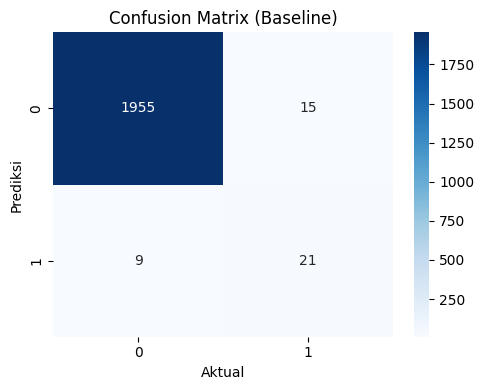

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_baseline = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(5,4))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Baseline)')
plt.xlabel('Aktual')
plt.ylabel('Prediksi')
plt.tight_layout()
plt.show()

In [25]:
y_prob_baseline = baseline_pipeline.predict_proba(X_test)[:,1]
roc_auc_baseline = roc_auc_score(y_test, y_prob_baseline)
print(roc_auc_baseline)

0.8461928934010153


**Decision Tree + Class Weight**

In [26]:
balanced_dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')

In [27]:
balanced_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', balanced_dt)
])

In [28]:
balanced_pipeline.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['amount',
                                                   'device_trust_score',
                                                   'velocity_last_24h',
                                                   'cardholder_age'])])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced',
                                        random_state=42))])

In [30]:
y_pred_balanced = balanced_pipeline.predict(X_test)

In [31]:
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
print(f"Hasil Akurasi dengan Data Uji :{accuracy_balanced:.4f}")
print(classification_report(y_test, y_pred_balanced))

Hasil Akurasi dengan Data Uji :0.9855
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1970
           1       0.52      0.47      0.49        30

    accuracy                           0.99      2000
   macro avg       0.76      0.73      0.74      2000
weighted avg       0.98      0.99      0.99      2000



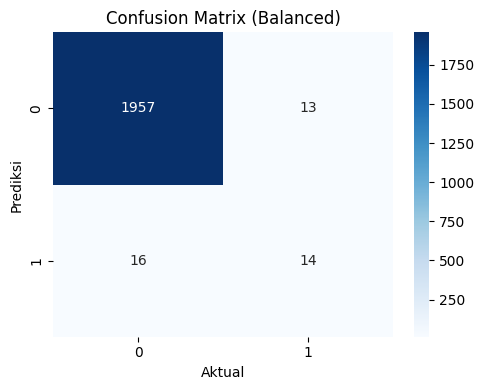

In [33]:
cm_balanced = confusion_matrix(y_test, y_pred_balanced)
plt.figure(figsize=(5,4))
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Balanced)')
plt.xlabel('Aktual')
plt.ylabel('Prediksi')
plt.tight_layout()
plt.show()

In [34]:
y_prob_balanced = balanced_pipeline.predict_proba(X_test)[:,1]
roc_auc_balanced = roc_auc_score(y_test, y_prob_balanced)
print(roc_auc_balanced)

0.7300338409475465


**Decision Tree + SMOTE**

In [35]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

smote_pipeline = Pipeline ([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', baseline_dt)
])

In [36]:
smote_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['amount',
                                                   'device_trust_score',
                                                   'velocity_last_24h',
                                                   'cardholder_age'])])),
                ('smote', SMOTE(random_state=42)),
                ('model', DecisionTreeClassifier(random_state=42))])

In [37]:
y_pred_smote = smote_pipeline.predict(X_test)

In [38]:
accuracy_smote = accuracy_score(y_test, y_pred_smote)
print(f'Hasil Akurasi Data Uji :{accuracy_smote:.4f}')
print(classification_report(y_test, y_pred_smote))

Hasil Akurasi Data Uji :0.9865
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1970
           1       0.54      0.63      0.58        30

    accuracy                           0.99      2000
   macro avg       0.77      0.81      0.79      2000
weighted avg       0.99      0.99      0.99      2000



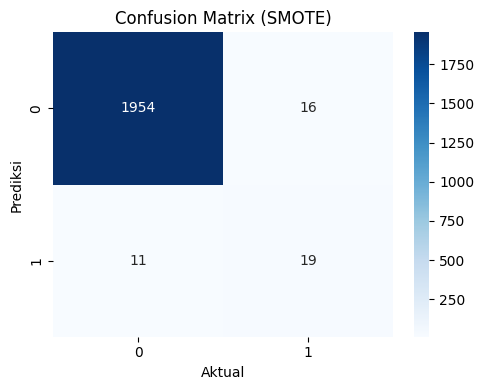

In [39]:
cm_smote = confusion_matrix(y_test, y_pred_smote)
plt.figure(figsize=(5,4))
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (SMOTE)')
plt.xlabel('Aktual')
plt.ylabel('Prediksi')
plt.tight_layout()
plt.show()

In [40]:
y_prob_smote = smote_pipeline.predict_proba(X_test)[:,1]
roc_auc_smote = roc_auc_score(y_test, y_prob_smote)
print(roc_auc_smote)

0.8126057529610828


**Model Hyperparameter Tuning Menggunakan Model Baseline**

In [41]:
params_grid = {
    'model__criterion' : ['gini','entropy','log_loss'],
    'model__max_depth' : [3, 5, 7, 10, 15, None],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf' : [1, 2, 5, 10],
    'model__ccp_alpha' : [0.0, 0.001, 0.005, 0.01]
}

In [43]:
from sklearn.model_selection import GridSearchCV

GridSearchDT = GridSearchCV(
    estimator = baseline_pipeline,
    param_grid = params_grid,
    cv = 5,
    scoring = 'f1',
    verbose = 2,
    n_jobs = -1
)

In [44]:
GridSearchDT.fit(X_train, y_train)

Fitting 5 folds for each of 1152 candidates, totalling 5760 fits


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['amount',
                                                                          'device_trust_score',
                                                                          'velocity_last_24h',
                                                                          'cardholder_age'])])),
                                       ('model',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__ccp_alpha': [0.0, 0.001, 0.005, 0.01],
                         'model__criterion': ['gini', 'entropy', 'log_loss'],
                         'model__max_depth': [3, 5, 7, 10, 15, None],
                         'model__min_samples_leaf': [1, 2, 5, 10],
                         'model__min_samples_split': [2, 5, 10, 20]},
             scoring='f1', verbose=2)

In [45]:
print(GridSearchDT.best_params_)

{'model__ccp_alpha': 0.0, 'model__criterion': 'entropy', 'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5}


In [46]:
best_dt = GridSearchDT.best_estimator_

In [47]:
y_pred = best_dt.predict(X_test)

In [48]:
accuracy = accuracy_score (y_test, y_pred)
print(f'Hasil Akurasi dari Data Uji :{accuracy:.4f}')
print(classification_report(y_test, y_pred))

Hasil Akurasi dari Data Uji :0.9920
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1970
           1       0.71      0.80      0.75        30

    accuracy                           0.99      2000
   macro avg       0.85      0.90      0.87      2000
weighted avg       0.99      0.99      0.99      2000



In [49]:
y_prob = best_dt.predict_proba(X_test)[:,1]
print('ROC AUC:', roc_auc_score(y_test, y_prob))

ROC AUC: 0.9473942470389172


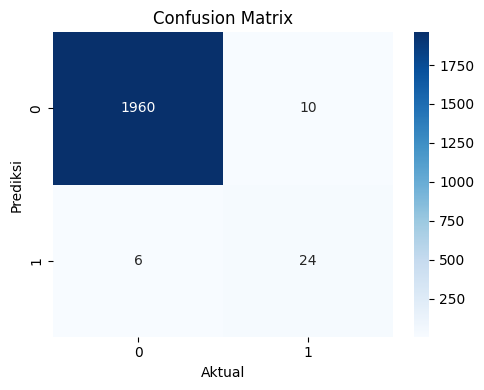

In [51]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Aktual')
plt.ylabel('Prediksi')
plt.tight_layout()
plt.show()

In [53]:
features_names = best_dt.named_steps[
    'preprocessor'
].get_feature_names_out()

importances = best_dt.named_steps[
    'model'
].feature_importances_

In [54]:
importance_df = pd.DataFrame({
    'Feature' : features_names,
    'Importances' : importances
 })
importance_df = importance_df.sort_values(
    by='Importances',
    ascending=False
)
importance_df

,Feature,Importances
1,num__device_trust_score,0.208971
2,num__velocity_last_24h,0.181638
7,remainder__location_mismatch,0.150500
6,remainder__foreign_transaction,0.138487
4,remainder__hour_sin,0.105397
5,remainder__hour_cos,0.102750
0,num__amount,0.088438
3,num__cardholder_age,0.023818


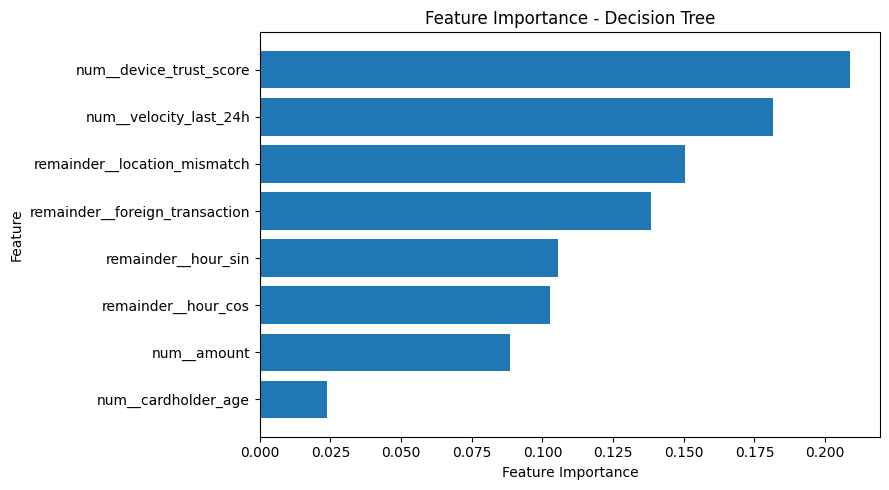

In [56]:
plt.figure(figsize=(9,5))
plt.barh(
    importance_df['Feature'],
    importance_df['Importances']
)
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance - Decision Tree')
plt.tight_layout()
plt.show()